In [1]:
# notebooks/01_eda_raw.ipynb (cell by cell)

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/bgl_cleaned.parquet")
print(df.shape)
df.head()

(4713483, 10)


,label,timestamp,date,node,time,node_repeat,type,component,level,content
0,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.363779,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
1,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.527847,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
2,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.675872,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
3,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.823719,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
4,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.982731,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected


Step 2: Class balance (label ≠ "-" means a real alert)

In [2]:
# Class balance (label ≠ "-" means a real alert)
df["is_anomaly"] = df["label"] != "-"

counts = df["is_anomaly"].value_counts()
pct_anomaly = 100 * counts.get(True, 0) / len(df)

print(counts)
print(f"Anomaly rate: {pct_anomaly:.3f}%")

is_anomaly
False    4365023
True      348460
Name: count, dtype: Int64
Anomaly rate: 7.393%


Step 3: Volume over time

C:\Users\Karthih2\AppData\Local\Temp\ipykernel_18848\2323343493.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.set_index("time").resample("1H").size()


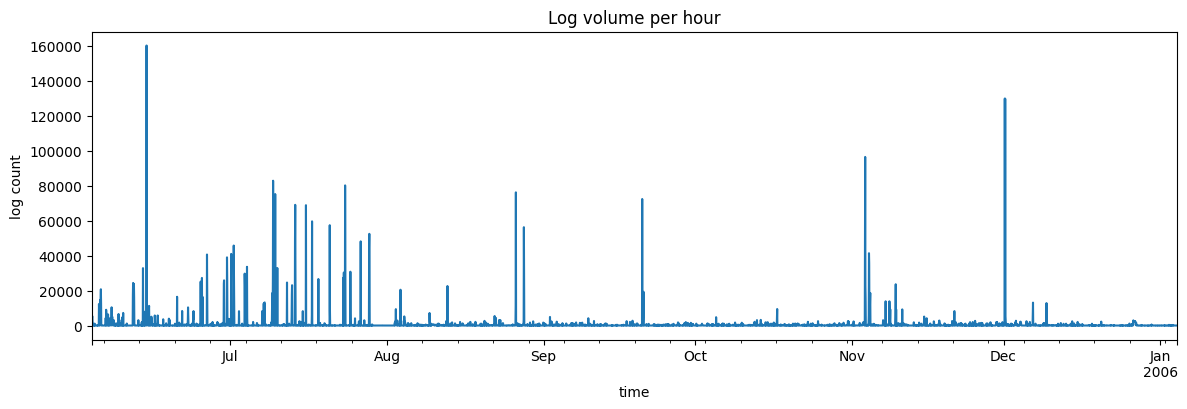

In [3]:
# Volume over time
df_hourly = df.set_index("time").resample("1H").size()

plt.figure(figsize=(14,4))
df_hourly.plot()
plt.title("Log volume per hour")
plt.ylabel("log count")
plt.savefig("../results/figures/volume_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()

Step 4: Log-level distribution

level
INFO       3701880
FATAL       854658
ERROR       112355
WARNING      23357
SEVERE       19213
FAILURE       1714
Kill           306
Name: count, dtype: Int64


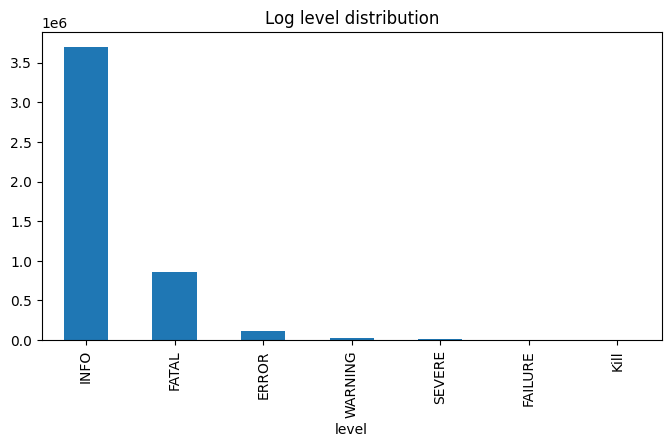

In [4]:
# Log-level distribution
level_counts = df["level"].value_counts()
print(level_counts)

level_counts.plot(kind="bar", figsize=(8,4), title="Log level distribution")
plt.savefig("../results/figures/log_level_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Step 5: Inter-arrival time distribution

count    4.713482e+06
mean     3.935145e+00
std      1.939928e+02
min      0.000000e+00
25%      1.820600e-02
50%      2.649600e-02
75%      3.830300e-02
max      1.765727e+05
Name: time, dtype: float64


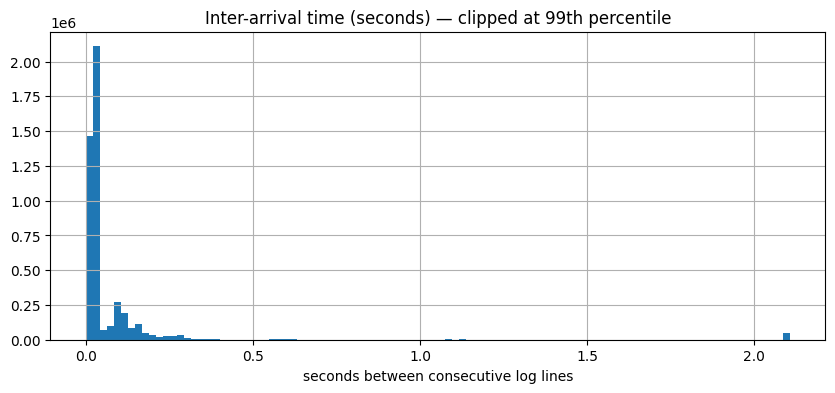

In [5]:
# Inter-arrival time distribution
df_sorted = df.sort_values("time")
inter_arrival = df_sorted["time"].diff().dt.total_seconds()

print(inter_arrival.describe())

plt.figure(figsize=(10,4))
inter_arrival.clip(upper=inter_arrival.quantile(0.99)).hist(bins=100)
plt.title("Inter-arrival time (seconds) — clipped at 99th percentile")
plt.xlabel("seconds between consecutive log lines")
plt.savefig("../results/figures/inter_arrival_time(clipped at 99th percentile).png", dpi=150, bbox_inches="tight")
plt.show()

Step 6: Component / node concentration

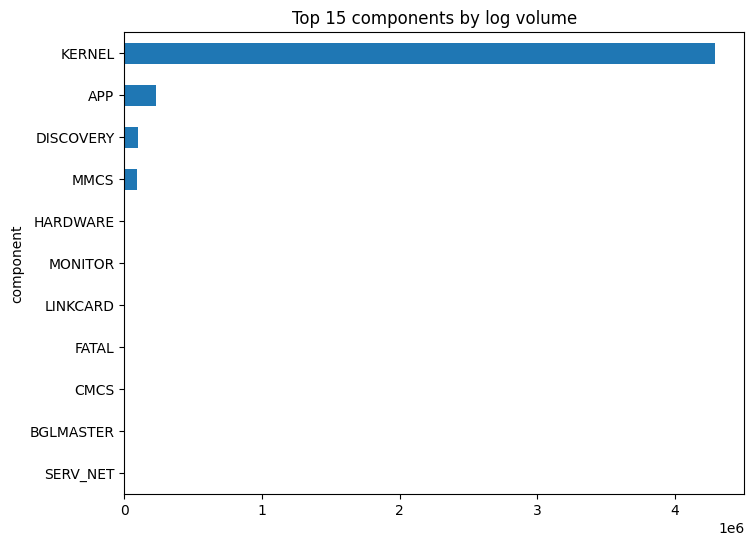

In [6]:
#Component / node concentration
df["component"].value_counts().head(15).plot(kind="barh", figsize=(8,6))
plt.title("Top 15 components by log volume")
plt.gca().invert_yaxis()
plt.savefig("../results/figures/Top_15_components_by_log_volume.png", dpi=150, bbox_inches="tight")
plt.show()

Step 7: Save the key numbers

In [7]:
# Save the key numbers
import json

summary = {
    "total_rows": len(df),
    "anomaly_count": int(counts.get(True, 0)),
    "anomaly_pct": round(pct_anomaly, 4),
    "dominant_log_level": level_counts.idxmax(),
    "level_distribution": level_counts.to_dict(),
    "inter_arrival_median_sec": float(inter_arrival.median()),
    "inter_arrival_p99_sec": float(inter_arrival.quantile(0.99)),
    "time_range": [str(df["time"].min()), str(df["time"].max())],
}

with open("../data/processed/eda_raw_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(summary)

{'total_rows': 4713483, 'anomaly_count': 348460, 'anomaly_pct': np.float64(7.3928), 'dominant_log_level': 'INFO', 'level_distribution': {'INFO': 3701880, 'FATAL': 854658, 'ERROR': 112355, 'WARNING': 23357, 'SEVERE': 19213, 'FAILURE': 1714, 'Kill': 306}, 'inter_arrival_median_sec': 0.026496, 'inter_arrival_p99_sec': 2.1076822200000156, 'time_range': ['2005-06-03 15:42:50.363779', '2006-01-04 08:00:05.233639']}


In [8]:
weird = df[df["level"].isin(["single", "microseconds", "0x00544eb8,"])]
print(weird[["label","time","type","component","level","content"]].to_string())

Empty DataFrame
Columns: [label, time, type, component, level, content]
Index: []


In [11]:
sample = df[df["content"] == "instruction cache parity error corrected"].head(6)
print(sample[["time", "template_id", "template"]].to_string())

KeyError: "['template_id', 'template'] not in index"